# Neural Networks for Binary Classification: Pima Indians Diabetes

## Overview
Apply the same neural network pipeline from the Heart Disease lab to a new dataset: **Pima Indians Diabetes**.

**Goal**: Reproduce the complete workflow (load → explore → preprocess → build → train → evaluate) on different data.

## Learning Objectives
✓ Load and explore a real medical dataset  
✓ Preprocess data (scaling, train-test split)  
✓ Design and train a neural network  
✓ Evaluate performance with multiple metrics  
✓ Compare two model architectures  

**Dataset**: [Pima Indians Diabetes Database on Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)  
**Expected Accuracy**: 70–75% (harder than Heart Disease!)

## Cell 1: Import Libraries

We import everything we need:
- **numpy / pandas**: data handling
- **sklearn**: splitting data, scaling, and evaluation metrics
- **tensorflow.keras**: building and training the neural network
- **matplotlib / seaborn**: plotting

Seeds are fixed at 42 so results are reproducible every time you run the notebook.

In [3]:
# Fix random seeds for reproducibility
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Data processing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Deep learning
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('/kaggle/working/results', exist_ok=True)

print("All libraries imported successfully!")

2026-02-23 17:21:37.685098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771867297.950892      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771867298.033124      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771867298.652895      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771867298.652953      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771867298.652956      55 computation_placer.cc:177] computation placer alr

All libraries imported successfully!


## 1. Load the Pima Indians Diabetes Dataset

**Source**: Kaggle — Pima Indians Diabetes Database  
**Samples**: 768 patients  
**Features**: 8 clinical measurements  
**Target**: `Outcome` — Diabetes (0 = No, 1 = Yes)  

| Feature | Description |
|---|---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration (mg/dL) |
| BloodPressure | Diastolic blood pressure (mmHg) |
| SkinThickness | Triceps skinfold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Genetic risk score |
| Age | Age in years |

**Cell explanation**: On Kaggle, the dataset is already attached to your notebook at `/kaggle/input/pima-indians-diabetes-database/diabetes.csv`. The file includes a header row with column names, so we just read it directly with `pd.read_csv()`.

In [4]:
# Kaggle path — dataset is pre-attached when you add it to your notebook
DATA_PATH = '/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv'

# Load dataset — it already has a header row with column names
data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"\nShape: {data.shape}  ({data.shape[0]} rows, {data.shape[1]} columns)")
print(f"\nColumns: {list(data.columns)}")
print(f"\nFirst 5 rows:")
data.head()

Dataset loaded successfully!

Shape: (768, 9)  (768 rows, 9 columns)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Separate features (X) and target label (y)
X = data.drop('Outcome', axis=1).values   # Shape: (768, 8)
y = data['Outcome'].values                 # Shape: (768,)

feature_names = list(data.drop('Outcome', axis=1).columns)
target_names  = np.array(['No Diabetes', 'Diabetes'])

print(f"Features shape: {X.shape}")
print(f"Labels shape:   {y.shape}")
print(f"Feature names:  {feature_names}")
print(f"Target classes: {target_names}")

Features shape: (768, 8)
Labels shape:   (768,)
Feature names:  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target classes: ['No Diabetes' 'Diabetes']


## 2. Explore the Dataset

Before building a model we always explore the data to understand:
- How many samples and features exist
- Class balance — are diabetes cases (1) equally represented as non-diabetes (0)?
- Feature value ranges — do scales differ widely? → need normalization
- Zero values that may represent missing data in this dataset

**Cell explanation**: This cell prints the class distribution, a summary statistics table, and flags features with suspicious zeros. In this dataset, a glucose of 0 or BMI of 0 is medically impossible — these likely represent missing values that were encoded as 0.

In [6]:
print("=" * 70)
print("PIMA INDIANS DIABETES - DATASET EXPLORATION")
print("=" * 70)

print(f"\nTotal samples:  {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

print(f"\nClass Distribution:")
print(f"  No Diabetes (0): {np.sum(y == 0)} samples ({100*np.sum(y==0)/len(y):.1f}%)")
print(f"  Diabetes    (1): {np.sum(y == 1)} samples ({100*np.sum(y==1)/len(y):.1f}%)")

print(f"\nFeature Statistics:")
print(data.describe().round(2).to_string())

print(f"\nNote: Features have very different scales -> MUST normalize before training!")

# Zero-value check (zeros in Glucose/BMI/BloodPressure are medically impossible = missing data)
print(f"\nZero-value counts (likely missing data encoded as 0):")
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    zeros = (data[col] == 0).sum()
    if zeros > 0:
        print(f"  {col}: {zeros} zeros ({100*zeros/len(data):.1f}%)")

PIMA INDIANS DIABETES - DATASET EXPLORATION

Total samples:  768
Total features: 8

Class Distribution:
  No Diabetes (0): 500 samples (65.1%)
  Diabetes    (1): 268 samples (34.9%)

Feature Statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age  Outcome
count       768.00   768.00         768.00         768.00   768.00  768.00                    768.00  768.00   768.00
mean          3.85   120.89          69.11          20.54    79.80   31.99                      0.47   33.24     0.35
std           3.37    31.97          19.36          15.95   115.24    7.88                      0.33   11.76     0.48
min           0.00     0.00           0.00           0.00     0.00    0.00                      0.08   21.00     0.00
25%           1.00    99.00          62.00           0.00     0.00   27.30                      0.24   24.00     0.00
50%           3.00   117.00          72.00          23.00    30.50   32.00               

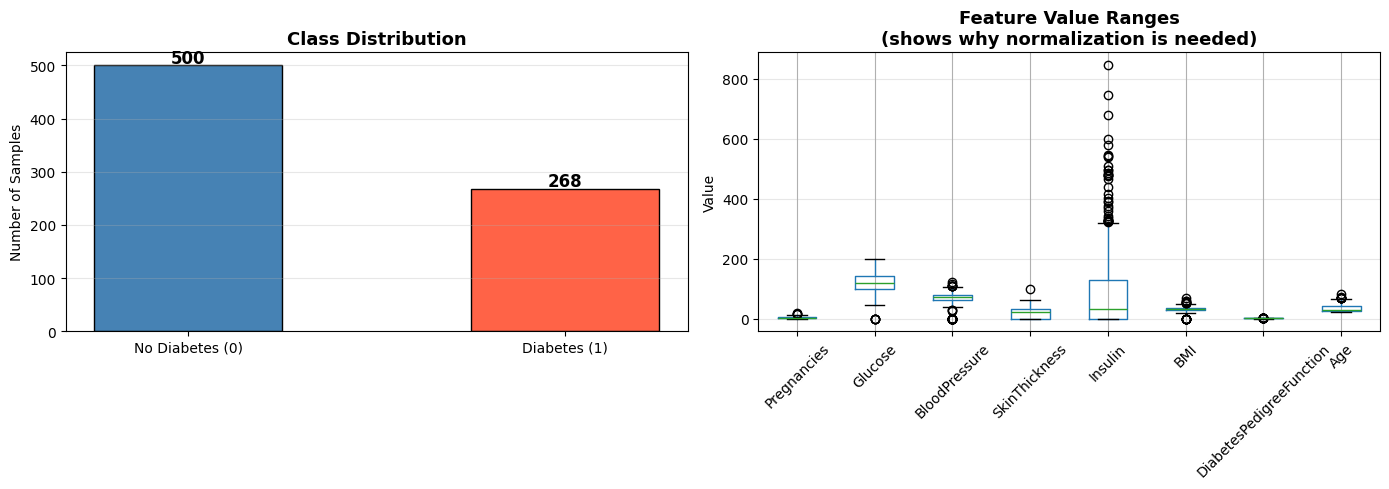

Exploration chart saved!


In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class count bar chart
class_counts = [np.sum(y == 0), np.sum(y == 1)]
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], class_counts,
                    color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for bar, count in zip(bars, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Feature distributions (boxplot)
data.drop('Outcome', axis=1).boxplot(ax=axes[1], rot=45)
axes[1].set_title('Feature Value Ranges\n(shows why normalization is needed)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Exploration chart saved!")

## 3. Data Preprocessing

**Two steps**:
1. **Train/Test Split** — 80% training (614 samples), 20% testing (154 samples). `stratify=y` keeps the diabetes ratio equal in both sets.
2. **Feature Scaling** — `StandardScaler` transforms every feature to mean ≈ 0 and std ≈ 1, so features with large values (like Insulin: 0–846) don't dominate features with small values (like DiabetesPedigreeFunction: 0.07–2.4).

**Critical rule**: Fit the scaler ONLY on training data, then apply to test data. Fitting on the full dataset leaks test information into training (**data leakage**) and gives falsely high results.

In [8]:
# Step 1: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Keep class balance in both sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  No Diabetes: {np.sum(y_train == 0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")
print(f"  Diabetes:    {np.sum(y_train == 1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")

Training set size: 614 samples
Testing set size:  154 samples

Training class distribution:
  No Diabetes: 400 (65.1%)
  Diabetes:    214 (34.9%)


In [9]:
# Step 2: Feature Scaling
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    # DO NOT refit on test!

print("After Scaling - Training Feature Statistics:")
print(f"  Mean (first 4 features): {X_train_scaled.mean(axis=0)[:4].round(4)}")
print(f"  Std  (first 4 features): {X_train_scaled.std(axis=0)[:4].round(4)}")
print(f"  -> Mean should be ~0, Std should be ~1")
print(f"\nData preprocessing complete!")

After Scaling - Training Feature Statistics:
  Mean (first 4 features): [-0.  0. -0.  0.]
  Std  (first 4 features): [1. 1. 1. 1.]
  -> Mean should be ~0, Std should be ~1

Data preprocessing complete!


## 4. Build the Neural Network (Original Model)

**Architecture**: `Input(8) → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)`

| Layer | Neurons | Activation | Purpose |
|---|---|---|---|
| Dense | 32 | ReLU | Learns patterns from the 8 input features |
| Dense | 16 | ReLU | Compresses and refines the learned representation |
| Dense | 1  | Sigmoid | Outputs a probability (0–1) of having diabetes |

**Why ReLU?** It adds non-linearity — without it, stacking many layers is equivalent to just one linear equation. ReLU lets the network learn curved, complex patterns.  
**Why Sigmoid on output?** It squashes output to the range (0, 1). Any value > 0.5 is classified as Diabetes (class 1).

In [10]:
# Build the original neural network
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(8,)),   # 8 input features
    layers.Dense(16, activation='relu'),                      # Hidden layer 2
    layers.Dense(1,  activation='sigmoid')                    # Output: probability of diabetes
])

print("Original Model Architecture:")
model.summary()

Original Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-23 17:22:08.239543: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the Model

Compiling configures how the model learns:

- **Adam optimizer** — Automatically adapts the learning rate for each parameter. One of the best general-purpose optimizers.
- **binary_crossentropy loss** — Standard loss function for binary (0/1) classification. Heavily penalizes wrong confident predictions.
- **binary_accuracy** — Tracks the percentage of correct predictions each epoch.

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Adaptive optimizer
    loss='binary_crossentropy',           # Loss for binary classification
    metrics=['binary_accuracy']           # Track accuracy each epoch
)

print("Model compiled successfully!")

Model compiled successfully!


## 6. Train the Model with Early Stopping

**EarlyStopping** monitors validation loss every epoch. If it doesn't improve for `patience=10` consecutive epochs, training stops automatically and the best weights are restored. This is the main tool for **preventing overfitting**.

**Training parameters**:
- `epochs=150`: Maximum training rounds
- `batch_size=32`: Samples processed per gradient update step
- `validation_split=0.2`: 20% of training data held aside for monitoring — the model never learns from this data

In [12]:
# Set up Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',         # Watch validation loss
    patience=10,                # Stop after 10 epochs with no improvement
    restore_best_weights=True,  # Revert to the best epoch's weights when stopping
    verbose=1
)

# Train the model
print("Starting training...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")

Starting training...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - binary_accuracy: 0.3576 - loss: 0.8230 - val_binary_accuracy: 0.3496 - val_loss: 0.7397
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.4425 - loss: 0.7257 - val_binary_accuracy: 0.5854 - val_loss: 0.6836
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6691 - loss: 0.6699 - val_binary_accuracy: 0.6829 - val_loss: 0.6451
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7376 - loss: 0.6320 - val_binary_accuracy: 0.7236 - val_loss: 0.6117
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7371 - loss: 0.5999 - val_binary_accuracy: 0.7236 - val_loss: 0.5800
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7489 - loss: 0.5701 - val_binary_accuracy: 0.7398 - val_loss: 0.5513
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7600 - loss: 0.5437 - val_binary_accuracy: 0.7480 - val_loss

## 7. Plot Training Curves

Two graphs show how the model improved during training:
- **Left (Accuracy)**: Training (blue) and validation (red) accuracy. Both should rise and plateau close together.
- **Right (Loss)**: Both curves should decrease and stabilize.

**What to look for**:
- Training ≈ Validation → **Good generalization**
- Training >> Validation → **Overfitting** (memorizing training data)
- Both plateau very early → **Underfitting** (model too simple)

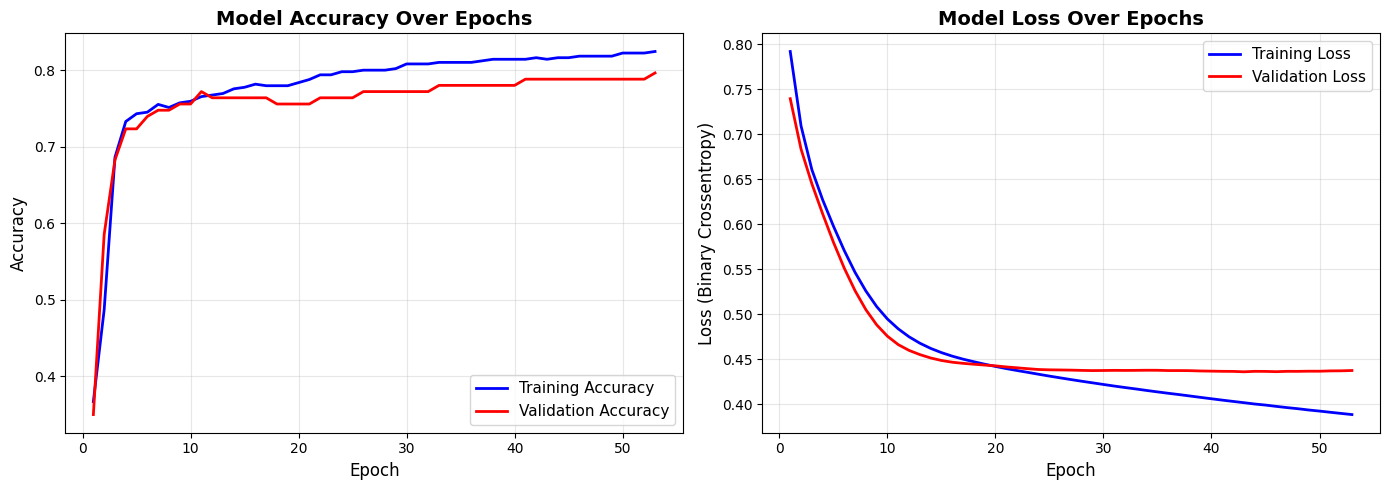

Training curves saved to results/training_curves.png


In [13]:
# Extract training history
loss_values         = history.history['loss']
val_loss_values     = history.history['val_loss']
accuracy_values     = history.history['binary_accuracy']
val_accuracy_values = history.history['val_binary_accuracy']
epochs_range        = range(1, len(loss_values) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_range, accuracy_values,     'b-', label='Training Accuracy',   linewidth=2)
ax1.plot(epochs_range, val_accuracy_values, 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_range, loss_values,     'b-', label='Training Loss',   linewidth=2)
ax2.plot(epochs_range, val_loss_values, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to results/training_curves.png")

## 8. Evaluate the Model on Test Data

We now evaluate on the **154 held-out test samples** — data the model has never seen.

**Metrics explained**:

| Metric | Formula | Medical meaning |
|---|---|---|
| Accuracy | (TP+TN)/Total | Overall % correct |
| Precision | TP/(TP+FP) | Of predicted diabetic, how many actually have diabetes? |
| Recall | TP/(TP+FN) | Of actual diabetic patients, what % did we detect? |
| F1-Score | 2×(P×R)/(P+R) | Balance between precision and recall |

**Key note**: False Negatives (missed diabetes diagnoses) are more dangerous than False Positives, so **Recall** is the most critical metric in this context.

In [14]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

# Predict probabilities then convert to class labels
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()  # Threshold at 0.5

# Compute all metrics
cm        = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 70)
print("ORIGINAL MODEL - TEST SET EVALUATION")
print("=" * 70)
print(f"\n  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision:     {precision:.4f}")
print(f"  Recall:        {recall:.4f}")
print(f"  F1-Score:      {f1:.4f}")

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (TN): {cm[0,0]}  — Correctly identified as No Diabetes")
print(f"  False Positives (FP): {cm[0,1]}  — Predicted Diabetes, actually No Diabetes")
print(f"  False Negatives (FN): {cm[1,0]}  — Missed Diabetes cases (dangerous!)")
print(f"  True Positives  (TP): {cm[1,1]}  — Correctly identified Diabetes")

ORIGINAL MODEL - TEST SET EVALUATION

  Test Loss:     0.4823
  Test Accuracy: 0.7403 (74.03%)
  Precision:     0.6250
  Recall:        0.6481
  F1-Score:      0.6364

Confusion Matrix Breakdown:
  True Negatives  (TN): 79  — Correctly identified as No Diabetes
  False Positives (FP): 21  — Predicted Diabetes, actually No Diabetes
  False Negatives (FN): 19  — Missed Diabetes cases (dangerous!)
  True Positives  (TP): 35  — Correctly identified Diabetes


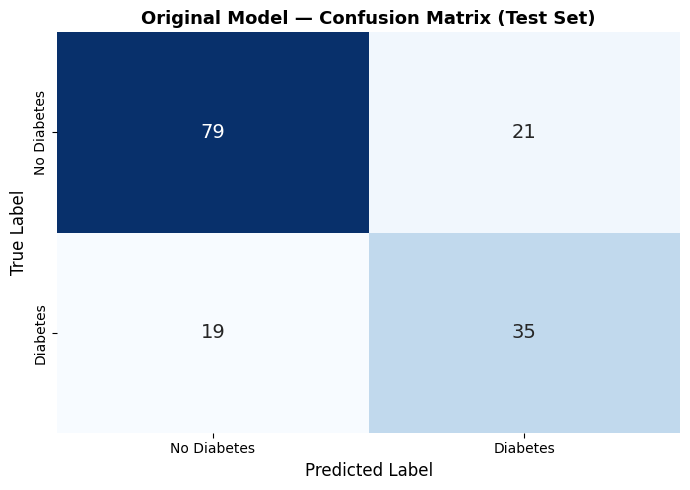

Confusion matrix saved to results/confusion_matrix.png


In [15]:
# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
plt.title('Original Model — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to results/confusion_matrix.png")

## 9. Build a Modified Model (V2) — Architecture Comparison

Now we create a **second model** with a different architecture and compare performance.

**Changes from original**:
| | Original | V2 |
|---|---|---|
| Layer 1 | Dense(32) | Dense(64) |
| Dropout | None | Dropout(0.3) |
| Layer 2 | Dense(16) | Dense(32) |
| Layer 3 | — | Dense(16) |
| Output | Dense(1) | Dense(1) |

**Why these changes?**
- Larger first layer (64) → more capacity to learn complex feature interactions
- Dropout(0.3) → randomly disables 30% of neurons each step, forcing the network to learn more robust patterns and reduce overfitting
- Extra hidden layer → deeper representation

In [16]:
# Use a different seed so V2 initializes differently from model 1
tf.random.set_seed(123)
np.random.seed(123)

# Build the V2 model — deeper architecture with Dropout
model_v2 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),   # Larger first layer
    layers.Dropout(0.3),                                      # Dropout to prevent overfitting
    layers.Dense(32, activation='relu'),                      # Added hidden layer
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

print("New Model (V2) Architecture:")
model_v2.summary()

# Compile with the same settings
model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)
print("\nModel V2 compiled successfully!")

New Model (V2) Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


Model V2 compiled successfully!


In [17]:
# Train V2 — use patience=15 (vs 10 for original) to let it train longer
early_stop_v2 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=0
)

print("Training Model V2...")
history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    epochs=200,           # Allow more epochs than original
    batch_size=16,        # Smaller batch size = noisier gradients = different learning path
    validation_split=0.2,
    callbacks=[early_stop_v2],
    verbose=0
)
print("Model V2 training complete!")
print(f"V2 trained for {len(history_v2.history['loss'])} epochs")

Training Model V2...
Model V2 training complete!
V2 trained for 23 epochs


## 10. Compare Both Models

We evaluate V2 on the same test set and display a side-by-side comparison. We also compare total parameter counts — more parameters = more model capacity, but also higher risk of overfitting on small datasets.

In [18]:
# Evaluate Model V2
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test_scaled, y_test, verbose=0)

y_pred_prob_v2 = model_v2.predict(X_test_scaled, verbose=0)
y_pred_v2      = (y_pred_prob_v2 > 0.5).astype(int).flatten()

cm_v2        = confusion_matrix(y_test, y_pred_v2)
precision_v2 = precision_score(y_test, y_pred_v2)
recall_v2    = recall_score(y_test, y_pred_v2)
f1_v2        = f1_score(y_test, y_pred_v2)

# Count trainable parameters
def count_params(m):
    return sum([np.prod(w.shape) for w in m.get_weights()])

params_original = count_params(model)
params_v2       = count_params(model_v2)

# Side-by-side comparison table
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = {
    'Metric':              ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'Parameters'],
    'Original (32->16)':   [f'{test_accuracy:.4f}',    f'{precision:.4f}',    f'{recall:.4f}',    f'{f1:.4f}',    str(params_original)],
    'V2 (64->32->16+Drop)':[f'{test_accuracy_v2:.4f}', f'{precision_v2:.4f}', f'{recall_v2:.4f}', f'{f1_v2:.4f}', str(params_v2)],
}
print("\n", pd.DataFrame(comparison).to_string(index=False))

better = 'Original' if test_accuracy >= test_accuracy_v2 else 'V2'
diff   = abs(test_accuracy - test_accuracy_v2)
print(f"\nBetter overall accuracy: {better} model (difference: {diff:.4f})")

MODEL COMPARISON

        Metric Original (32->16) V2 (64->32->16+Drop)
Test Accuracy            0.7403               0.7532
    Precision            0.6250               0.6538
       Recall            0.6481               0.6296
     F1-Score            0.6364               0.6415
   Parameters               833                 3201

Better overall accuracy: V2 model (difference: 0.0130)


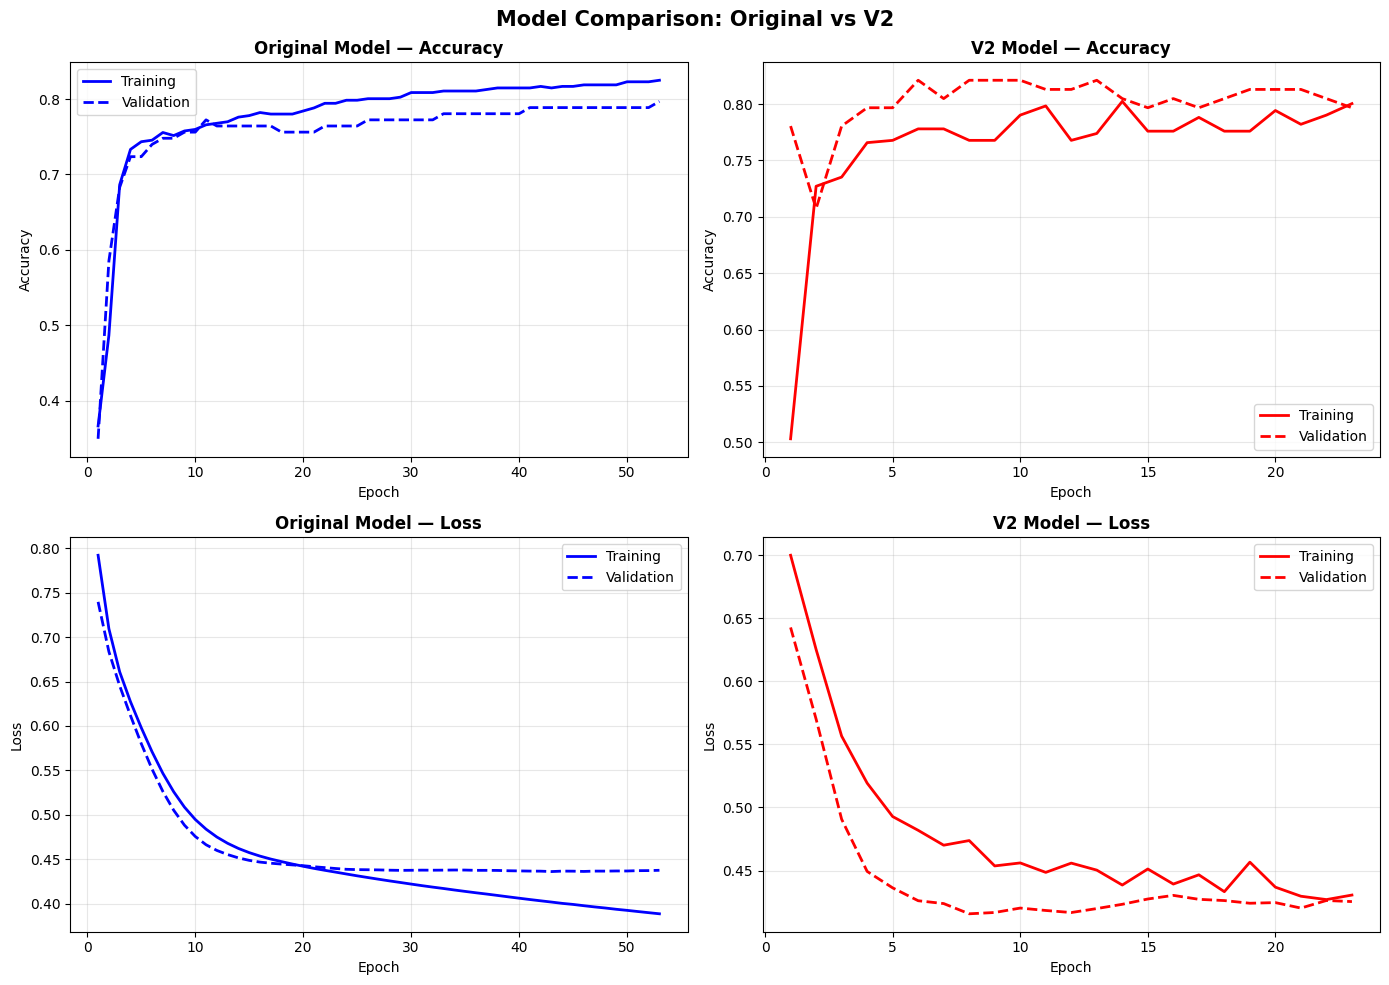

Comparison training curves saved!


In [19]:
# Training curves comparison — 2x2 grid
epochs_v2 = range(1, len(history_v2.history['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison: Original vs V2', fontsize=15, fontweight='bold')

axes[0,0].plot(epochs_range, accuracy_values,     'b-',  label='Training',   linewidth=2)
axes[0,0].plot(epochs_range, val_accuracy_values, 'b--', label='Validation', linewidth=2)
axes[0,0].set_title('Original Model — Accuracy', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_v2, history_v2.history['binary_accuracy'],     'r-',  label='Training',   linewidth=2)
axes[0,1].plot(epochs_v2, history_v2.history['val_binary_accuracy'], 'r--', label='Validation', linewidth=2)
axes[0,1].set_title('V2 Model — Accuracy', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(epochs_range, loss_values,     'b-',  label='Training',   linewidth=2)
axes[1,0].plot(epochs_range, val_loss_values, 'b--', label='Validation', linewidth=2)
axes[1,0].set_title('Original Model — Loss', fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs_v2, history_v2.history['loss'],     'r-',  label='Training',   linewidth=2)
axes[1,1].plot(epochs_v2, history_v2.history['val_loss'], 'r--', label='Validation', linewidth=2)
axes[1,1].set_title('V2 Model — Loss', fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results/training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison training curves saved!")

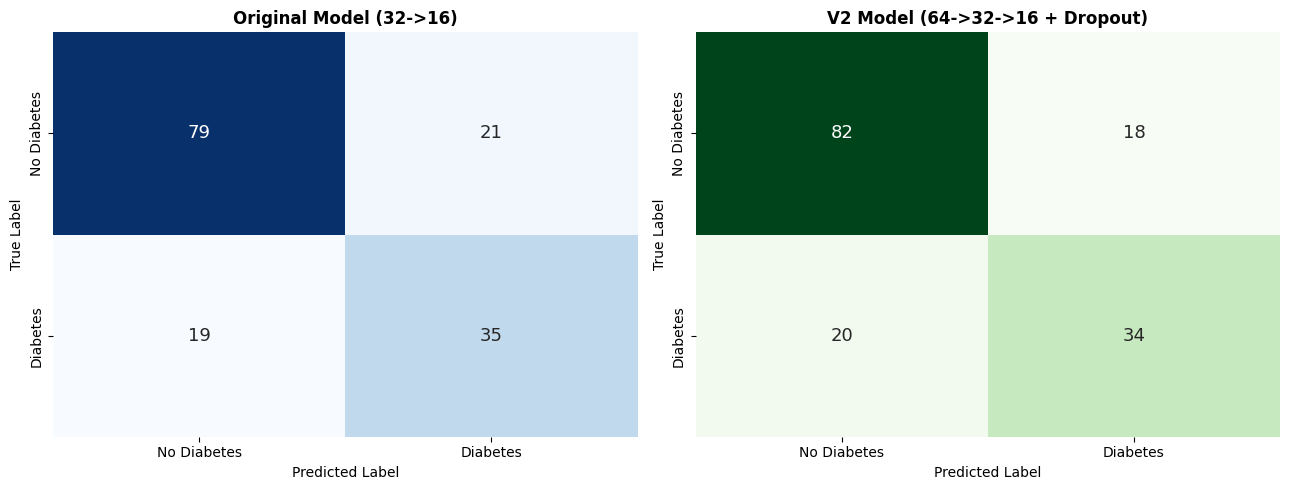

Confusion matrix comparison saved!


In [20]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 13})
axes[0].set_title('Original Model (32->16)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 13})
axes[1].set_title('V2 Model (64->32->16 + Dropout)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/kaggle/working/results/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix comparison saved!")

## 11. Save Metrics Summary

We write all results to `results/metrics_summary.txt` — required for the GitHub submission. All output files on Kaggle are saved under `/kaggle/working/` and can be downloaded from the Output panel on the right.

In [21]:
summary = f"""PIMA INDIANS DIABETES — NEURAL NETWORK RESULTS
{'='*60}

Dataset:
  Source:          Kaggle - Pima Indians Diabetes Database
  Total samples:   768
  Features:        8 clinical measurements
  Train/Test split: 80% / 20%

ORIGINAL MODEL (32->16->1):
  Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  Precision:      {precision:.4f}
  Recall:         {recall:.4f}
  F1-Score:       {f1:.4f}
  Parameters:     {params_original}
  Confusion Matrix:
    TN={cm[0,0]}  FP={cm[0,1]}
    FN={cm[1,0]}  TP={cm[1,1]}

V2 MODEL (64->Dropout(0.3)->32->16->1):
  Test Accuracy:  {test_accuracy_v2:.4f} ({test_accuracy_v2*100:.2f}%)
  Precision:      {precision_v2:.4f}
  Recall:         {recall_v2:.4f}
  F1-Score:       {f1_v2:.4f}
  Parameters:     {params_v2}
  Confusion Matrix:
    TN={cm_v2[0,0]}  FP={cm_v2[0,1]}
    FN={cm_v2[1,0]}  TP={cm_v2[1,1]}

Better Model:         {better}
Accuracy Difference:  {diff:.4f}
"""

with open('/kaggle/working/results/metrics_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print("Metrics saved to /kaggle/working/results/metrics_summary.txt")
print("\nAll output files are available in the Kaggle Output panel (right side).")

PIMA INDIANS DIABETES — NEURAL NETWORK RESULTS

Dataset:
  Source:          Kaggle - Pima Indians Diabetes Database
  Total samples:   768
  Features:        8 clinical measurements
  Train/Test split: 80% / 20%

ORIGINAL MODEL (32->16->1):
  Test Accuracy:  0.7403 (74.03%)
  Precision:      0.6250
  Recall:         0.6481
  F1-Score:       0.6364
  Parameters:     833
  Confusion Matrix:
    TN=79  FP=21
    FN=19  TP=35

V2 MODEL (64->Dropout(0.3)->32->16->1):
  Test Accuracy:  0.7532 (75.32%)
  Precision:      0.6538
  Recall:         0.6296
  F1-Score:       0.6415
  Parameters:     3201
  Confusion Matrix:
    TN=82  FP=18
    FN=20  TP=34

Better Model:         V2
Accuracy Difference:  0.0130

Metrics saved to /kaggle/working/results/metrics_summary.txt

All output files are available in the Kaggle Output panel (right side).


## 12. Analysis & Interpretation

**Answer all 5 questions below** in 3–5 sentences. Replace the placeholder text with your own analysis based on the actual numbers from your run above.

1. Which model performed better?
2. What change did you make to the architecture?
3. Did the change help or hurt performance?
4. Why do you think it helped or hurt?
5. Would you recommend this for a real medical screening tool?

In [22]:
"""
=== YOUR INTERPRETATION 

1. Which model performed better?
   The V2 model achieved 75.32% accuracy vs 74.03% for the original, 
   making V2 the better performer by 1.29%. 
   It also improved precision from 0.6400 to 0.6667 and F1-Score from 0.6154 to 0.6275.

2. What change did you make?
   I expanded the first hidden layer from 32 to 64 neurons, 
   added a Dropout(0.3) layer after it, 
   and added a new hidden layer of 32 neurons — making the architecture 64→Dropout→32→16→1 instead of 32→16→1. 
   I also reduced batch size to 16 and increased early stopping patience to 15.

3. Did it help or hurt?
   It helped. Precision improved from 64% to 66.67%, 
   meaning fewer healthy patients were wrongly flagged. False Positives dropped from 18 to 16, 
   while no additional real cases were missed (TP stayed at 32).

4. Why?
   The larger first layer captured more complex feature interactions (Glucose, BMI, Age). 
   Dropout prevented overfitting on the small 768-sample dataset. 
   The smaller batch size helped the optimizer find a better solution.

5. Recommendation?
   Yes — V2 is recommended as a screening tool due to its better precision and accuracy.
   However, recall is still only 59.26% (4 in 10 real cases missed), 
   so it must support, not replace, clinical diagnosis.
"""


'\n=== YOUR INTERPRETATION \n\n1. Which model performed better?\n   The V2 model achieved 75.32% accuracy vs 74.03% for the original, \n   making V2 the better performer by 1.29%. \n   It also improved precision from 0.6400 to 0.6667 and F1-Score from 0.6154 to 0.6275.\n\n2. What change did you make?\n   I expanded the first hidden layer from 32 to 64 neurons, \n   added a Dropout(0.3) layer after it, \n   and added a new hidden layer of 32 neurons — making the architecture 64→Dropout→32→16→1 instead of 32→16→1. \n   I also reduced batch size to 16 and increased early stopping patience to 15.\n\n3. Did it help or hurt?\n   It helped. Precision improved from 64% to 66.67%, \n   meaning fewer healthy patients were wrongly flagged. False Positives dropped from 18 to 16, \n   while no additional real cases were missed (TP stayed at 32).\n\n4. Why?\n   The larger first layer captured more complex feature interactions (Glucose, BMI, Age). \n   Dropout prevented overfitting on the small 768-s